In [38]:
import re
import json
import random
import numpy as np
import pandas as pd

from IPython.display import display
from itertools import product
from scipy.optimize import linear_sum_assignment
from sentence_transformers import SentenceTransformer
from itertools import product
from concurrent.futures import ThreadPoolExecutor, as_completed


In [3]:
def generate_schema_variations(
    base_schema,
    entity_name_map,
    attribute_name_map,
    include_original_entity=True,
    include_original_attribute=True,
):
    """
    Generate all schema variations for one script only (Latin OR Cyrillic).

    Parameters
    ----------
    base_schema : dict
        Example:
        {
            "SkiKarta": [("cena", "NUMERIC"), ("vazi_od", "DATE")]
        }

    entity_name_map : dict
        Example:
        {
            "SkiKarta": ["Karta", "Vleznica", ...]
        }

    attribute_name_map : dict
        Example:
        {
            "cena": ["price", "fee", ...]
        }

    include_original_entity : bool
        Whether to also include the original table name from base_schema
        as one of the possible variants.

    include_original_attribute : bool
        Whether to also include the original attribute name from base_schema
        as one of the possible variants.

    Returns
    -------
    list[dict]
        A list of schema dictionaries, each one being a full variation.
    """

    table_options = []  # list of tuples: (base_table_name, possible_table_names, attr_defs)

    for base_table_name, attrs in base_schema.items():
        # Entity/table name candidates
        entity_variants = list(entity_name_map.get(base_table_name, []))
        if include_original_entity and base_table_name not in entity_variants:
            entity_variants = [base_table_name] + entity_variants

        # Attribute candidates for this table
        attr_options = []
        for attr_name, sql_type in attrs:
            possible_attr_names = list(attribute_name_map.get(attr_name, []))
            if include_original_attribute and attr_name not in possible_attr_names:
                possible_attr_names = [attr_name] + possible_attr_names

            # store all possible concrete versions of this attribute
            attr_options.append([(candidate, sql_type) for candidate in possible_attr_names])

        table_options.append((entity_variants, attr_options))

    # Now build all full-schema combinations
    all_schema_variations = []

    # One choice of table name + one choice per attribute, for each table
    per_table_combinations = []
    for entity_variants, attr_options in table_options:
        # For this table:
        # choose 1 table name and 1 variant for each attribute
        table_variants = []
        for chosen_table_name in entity_variants:
            for chosen_attrs in product(*attr_options):
                table_variants.append((chosen_table_name, list(chosen_attrs)))
        per_table_combinations.append(table_variants)

    # Combine the chosen version of every table into one full schema
    for chosen_tables in product(*per_table_combinations):
        schema_variant = {}
        for table_name, attrs in chosen_tables:
            schema_variant[table_name] = attrs
        all_schema_variations.append(schema_variant)

    return all_schema_variations

In [4]:
def generate_all_script_separated_variations(
    base_schema,
    entity_names_lat,
    attribute_names_lat,
    entity_names_cyr,
    attribute_names_cyr,
    include_original_entity=True,
    include_original_attribute=True,
):
    """
    Generate Latin-only and Cyrillic-only schema variations separately.
    No Latin/Cyrillic mixing is done.

    Returns
    -------
    dict
        {
            "latin": [...],
            "cyrillic": [...]
        }
    """
    latin_variations = generate_schema_variations(
        base_schema=base_schema,
        entity_name_map=entity_names_lat,
        attribute_name_map=attribute_names_lat,
        include_original_entity=include_original_entity,
        include_original_attribute=include_original_attribute,
    )

    cyrillic_variations = generate_schema_variations(
        base_schema=base_schema,
        entity_name_map=entity_names_cyr,
        attribute_name_map=attribute_names_cyr,
        include_original_entity=include_original_entity,
        include_original_attribute=include_original_attribute,
    )

    return {
        "latin": latin_variations,
        "cyrillic": cyrillic_variations,
    }

In [5]:
def generate_limited_schema_variations(
    base_schema,
    entity_name_map,
    attribute_name_map,
    max_schemas=10,
    include_original_entity=True,
    include_original_attribute=True,
    seed=None,
):
    """
    Generate up to `max_schemas` schema variations for one script only
    (Latin OR Cyrillic), without mixing scripts.

    Returns a list of schema dictionaries.
    """
    rng = random.Random(seed)
    seen = set()
    results = []
    attempts = 0
    max_attempts = max_schemas * 50  # avoid infinite loops if variation space is small

    while len(results) < max_schemas and attempts < max_attempts:
        attempts += 1
        schema_variant = {}

        for base_table_name, attrs in base_schema.items():
            # choose table/entity name
            entity_variants = list(entity_name_map.get(base_table_name, []))
            if include_original_entity and base_table_name not in entity_variants:
                entity_variants = [base_table_name] + entity_variants

            chosen_table_name = rng.choice(entity_variants)

            # choose attribute names
            chosen_attrs = []
            for attr_name, sql_type in attrs:
                attr_variants = list(attribute_name_map.get(attr_name, []))
                if include_original_attribute and attr_name not in attr_variants:
                    attr_variants = [attr_name] + attr_variants

                chosen_attr_name = rng.choice(attr_variants)
                chosen_attrs.append((chosen_attr_name, sql_type))

            schema_variant[chosen_table_name] = chosen_attrs

        # make hashable signature to avoid duplicates
        signature = tuple(
            sorted(
                (table, tuple(attrs))
                for table, attrs in schema_variant.items()
            )
        )

        if signature not in seen:
            seen.add(signature)
            results.append(schema_variant)

    return results

In [6]:
def generate_latin_and_cyrillic_variations(
    base_schema,
    entity_names_lat,
    attribute_names_lat,
    entity_names_cyr,
    attribute_names_cyr,
    max_latin=10,
    max_cyrillic=10,
    include_original_entity=True,
    include_original_attribute=True,
    seed=None,
):
    """
    Generate a limited number of Latin-only and Cyrillic-only schemas.
    No mixing between scripts.
    """
    latin_variations = generate_limited_schema_variations(
        base_schema=base_schema,
        entity_name_map=entity_names_lat,
        attribute_name_map=attribute_names_lat,
        max_schemas=max_latin,
        include_original_entity=include_original_entity,
        include_original_attribute=include_original_attribute,
        seed=seed,
    )

    cyrillic_variations = generate_limited_schema_variations(
        base_schema=base_schema,
        entity_name_map=entity_names_cyr,
        attribute_name_map=attribute_names_cyr,
        max_schemas=max_cyrillic,
        include_original_entity=include_original_entity,
        include_original_attribute=include_original_attribute,
        seed=None if seed is None else seed + 1,
    )

    return {
        "latin": latin_variations,
        "cyrillic": cyrillic_variations,
    }

In [7]:
def format_schema_as_code(schema, var_name="SCHEMA"):
    lines = [f"{var_name} = {{"]
    for table_name, attrs in schema.items():
        lines.append(f'    "{table_name}": [')
        for attr_name, sql_type in attrs:
            lines.append(f'        ("{attr_name}", "{sql_type}"),')
        lines.append("    ],")
    lines.append("}")
    return "\n".join(lines)

In [32]:
diagram2_schema = {
    "SkiSlope": ["name", "difficulty", "length", "lift_id"],
    "Skier": ["age", "name", "last_name", "skill_level"],
    "SkiLift": ["name", "capacity", "length", "status"],
    "Instructor": ["name", "surname", "license_level", "experience_years"],
    "SkiEquipment": ["type", "brand", "size", "status"],
    "SkiPass": ["valid_from", "valid_to", "price",  "skier_id"]
}
diagram1_schema = {
    "SkiKarta": ["cena", "vazi_od", "vazi_do", "skijac_id"],
    "SkiLift": ["ime", "kapacitet", "dolzina", "status"],
    "SkiStaza": ["ime", "tezina", "dolzina", "lift_id"],
    "Skijac": ["ime", "prezime", "vozrast", "nivo_na_veshtina"],
    "Oprema": ["tip", "golemina", "brend", "status"],
    "Instructor": ["ime", "prezime", "nivo_na_licenca", "godini_iskustvo"]
}
entity_names_lat={
    "SkiKarta": ["Karta","Vleznica","SkiVleznica","LiftPass","SkiLiftTicket","SkiTicket"],
    "SkiLift":["Lift","Zicara","Zhichara","Gondola"],
    "SkiStaza":["Stage","Staza","Teren","SkiStage","SkiTeren","Slope"],
    "Skijac":["Skier","Skijach","Natprevaruvach"],
    "Oprema":["Gear","SkiingGear","Equipment"],
    "Instructor":["Instruktor","Tutor","Instructor","Teacher"]
}

entity_names_cyr={
        "SkiKarta": ["Карта","Влезница","СкиВлезница","ЛифтДозвола","СкиЛифтКарта","СкиКарта"],
    "SkiLift":["Лифт","Жичара","Гондола","Зицара"],
    "SkiStaza":["Стаза","Терен","СкиСтаза","Удолница"],
    "Skijac":["Скијач","Натпреварувач"],
    "Oprema":["Опрема","Скиопрема"],
    "Instructor":["Инструктор","Професор","Тренер"]
}

attribute_names_lat={
    "cena": ["price","fee","cost","payment","amount"],
    "vazi_od": ["from","date_from","start","start_date","begin_date","pochetok","pochetna_data","pocetok","pocnuva_na"],
    "vazi_do": ["untill","till","to","date_till","end","end_date","begin_date","kraj","zavrshuva_na","kraen_datum"],
    "skijac_id": ["ski_id","id","skier_id","id_skier"],
    "ime": ["name","naziv"],
    "kapacitet": ["capacity","max_weight","max_cap","max_load"],
    "dolzina": ["length","size","golemina"],
    "status":["sostojba","zafatenost"],
    "tezina": ["weight","level","hardness","rating"],
    "lift_id": ["lift_number","id"],
    "prezime": ["surname"],
    "vozrast": ["godini","age","starost"],
    "nivo_na_veshtina": ["ability","capabilities","level","sposobnost"],
    "tip":["type","version","verzija"],
    "golemina": ["size","dolzina","gabaritnost"],
    "brend": ["brand","marka"],
    "nivo_na_licenca": ["licence_level","dozvola_nivo","dozvola"],
    "godini_iskustvo": ["years_experience"]
}
attribute_names_cyr={
    "cena": ["цена"],
    "vazi_od": ["од","дата_од","почеток","почетна_дата","почнал_на"],
    "vazi_do": ["до","се_до","дата_до","крај","крајна_дата","завршува_на",],
    "skijac_id": ["ски_ид","скијач_ид","скијач_ид"],
    "ime": ["име","назив"],
    "kapacitet": ["капацитет","носивост","макс_капацитет"],
    "dolzina": ["должина","големина"],
    "status":["состојба","зафатеност"],
    "tezina": ["тежина","тезина","ниво","оценка"],
    "lift_id": ["лифт_ид","ид"],
    "prezime": ["презиме"],
    "vozrast": ["години","возраст","старост"],
    "nivo_na_veshtina": ["способност","можности","ниво"],
    "tip":["тип","верзија"],
    "golemina": ["големина","должина","габаритност"],
    "brend": ["бренд","марка"],
    "nivo_na_licenca": ["ниво_лиценца","дозвола_ниво","дозвола"],
    "godini_iskustvo": ["години_искуство"]
}
PROFESSOR_SCHEMA = {
    "SkiKarta": [
        ("cena",       "NUMERIC"),
        ("vazi_od",    "DATE"),
        ("vazi_do",    "DATE"),
        ("skijac_id",  "INTEGER"),
    ],
    "SkiLift": [
        ("ime",        "TEXT"),
        ("kapacitet",  "INTEGER"),
        ("dolzina",    "NUMERIC"),
        ("status",     "TEXT"),
    ],
    "SkiStaza": [
        ("ime",        "TEXT"),
        ("tezina",     "TEXT"),
        ("dolzina",    "NUMERIC"),
        ("lift_id",    "INTEGER"),
    ],
    "Skijac": [
        ("ime",                 "TEXT"),
        ("prezime",             "TEXT"),
        ("vozrast",             "INTEGER"),
        ("nivo_na_veshtina",    "TEXT"),
    ],
    "Oprema": [
        ("tip",        "TEXT"),
        ("golemina",   "TEXT"),
        ("brend",      "TEXT"),
        ("status",     "TEXT"),
    ],
    "Instructor": [
        ("ime",                "TEXT"),
        ("prezime",            "TEXT"),
        ("nivo_na_licenca",    "TEXT"),
        ("godini_iskustvo",    "INTEGER"),
    ],
}

# print("Latin schemas:", len(schemas["latin"]))
# print("Cyrillic schemas:", len(schemas["cyrillic"]))
#
# print("\nFirst Latin schema:")
# print(format_schema_as_code(schemas["latin"][0]))
#
# print("\nFirst Cyrillic schema:")
# print(format_schema_as_code(schemas["cyrillic"][0]))


In [9]:
# Format: { "TableName": [("attr_name", "SQL_TYPE"), ...] }

# ── Professor solution (diagram1) ──────────────────────────────────────────
PROFESSOR_SCHEMA = {
    "SkiKarta": [
        ("cena", "NUMERIC"),
        ("vazi_od", "DATE"),
        ("vazi_do", "DATE"),
        ("skijac_id", "INTEGER"),
    ],
    "SkiLift": [
        ("ime", "TEXT"),
        ("kapacitet", "INTEGER"),
        ("dolzina", "NUMERIC"),
        ("status", "TEXT"),
    ],
    "SkiStaza": [
        ("ime", "TEXT"),
        ("tezina", "TEXT"),
        ("dolzina", "NUMERIC"),
        ("lift_id", "INTEGER"),
    ],
    "Skijac": [
        ("ime", "TEXT"),
        ("prezime", "TEXT"),
        ("vozrast", "INTEGER"),
        ("nivo_na_veshtina", "TEXT"),
    ],
    "Oprema": [
        ("tip", "TEXT"),
        ("golemina", "TEXT"),
        ("brend", "TEXT"),
        ("status", "TEXT"),
    ],
    "Instructor": [
        ("ime", "TEXT"),
        ("prezime", "TEXT"),
        ("nivo_na_licenca", "TEXT"),
        ("godini_iskustvo", "INTEGER"),
    ],
}

# ── Student solution (diagram2) ─────────────────────────────────────────────
STUDENT_SCHEMA = {
    "SkiSlope": [
        ("name", "TEXT"),
        ("difficulty", "TEXT"),
        ("length", "NUMERIC"),
        ("lift_id", "INTEGER"),
    ],
    "Skier": [
        ("age", "INTEGER"),
        ("name", "TEXT"),
        ("last_name", "TEXT"),
        ("skill_level", "TEXT"),
    ],
    "SkiLift": [
        ("name", "TEXT"),
        ("capacity", "INTEGER"),
        ("length", "NUMERIC"),
        ("status", "TEXT"),
    ],
    "Instructor": [
        ("name", "TEXT"),
        ("surname", "TEXT"),
        ("license_level", "TEXT"),
        ("experience_years", "INTEGER"),
    ],
    "SkiEquipment": [
        ("type", "TEXT"),
        ("brand", "TEXT"),
        ("size", "TEXT"),
        ("status", "TEXT"),
    ],
    "SkiPass": [
        ("valid_from", "DATE"),
        ("valid_to", "DATE"),
        ("price", "NUMERIC"),
        ("skier_id", "INTEGER"),
    ],
}

print(f'Professor tables : {list(PROFESSOR_SCHEMA.keys())}')
print(f'Student tables   : {list(STUDENT_SCHEMA.keys())}')

Professor tables : ['SkiKarta', 'SkiLift', 'SkiStaza', 'Skijac', 'Oprema', 'Instructor']
Student tables   : ['SkiSlope', 'Skier', 'SkiLift', 'Instructor', 'SkiEquipment', 'SkiPass']


In [10]:
# Minimum cosine similarity to consider a pair matched (0.0 – 1.0)
TABLE_MATCH_THRESHOLD = 0.40
ATTR_MATCH_THRESHOLD  = 0.35   # slightly lower now — type signal compensates

# Signal weights for TABLE matching (must sum to 1.0)
W_NAME   = 0.40   # table name embedding similarity
W_ATTRS  = 0.40   # attribute-set embedding similarity
W_STRUCT = 0.10   # structural similarity (attribute count ratio)
W_TYPES  = 0.10   # type-distribution similarity

# Weight of type compatibility in ATTRIBUTE matching (0.0 = ignore types)
W_ATTR_NAME = 0.65   # name embedding similarity
W_ATTR_TYPE = 0.35   # SQL type compatibility bonus

# Model name
MODEL_NAME = "paraphrase-multilingual-MiniLM-L12-v2"  # ~120 MB, fast

print('Config loaded ✓')



Config loaded ✓


In [11]:
# SQL type normalisation map — collapse vendor-specific types into canonical groups
TYPE_GROUPS = {
    'integer': {'int', 'integer', 'bigint', 'smallint', 'tinyint', 'serial', 'number'},
    'text':    {'varchar', 'nvarchar', 'char', 'nchar', 'text', 'string', 'clob'},
    'decimal': {'decimal', 'numeric', 'float', 'double', 'real', 'money'},
    'date':    {'date'},
    'datetime':{'datetime', 'timestamp', 'time'},
    'boolean': {'boolean', 'bool', 'bit'},
    'binary':  {'blob', 'binary', 'varbinary', 'bytea'},
}

# Build reverse map: raw_type -> canonical_group
_TYPE_LOOKUP = {raw: group for group, raws in TYPE_GROUPS.items() for raw in raws}


def normalise_type(t: str) -> str:
    """Normalise a SQL type string to a canonical group name."""
    base = t.lower().split('(')[0].strip()   # strip length: VARCHAR(255) -> varchar
    return _TYPE_LOOKUP.get(base, base)       # unknown types kept as-is


def type_compatible(t1: str, t2: str) -> float:
    """
    Returns a compatibility score between two SQL types:
      1.0  — same canonical group  (INTEGER vs BIGINT)
      0.5  — related groups        (integer vs decimal — both numeric)
      0.0  — incompatible          (text vs date)
    """
    NUMERIC = {'integer', 'decimal'}
    TEMPORAL = {'date', 'datetime'}
    n1, n2 = normalise_type(t1), normalise_type(t2)
    if n1 == n2:
        return 1.0
    if n1 in NUMERIC and n2 in NUMERIC:
        return 0.5
    if n1 in TEMPORAL and n2 in TEMPORAL:
        return 0.5
    return 0.0


def type_distribution_similarity(prof_attrs: list, stud_attrs: list) -> float:
    """
    Compare the bag-of-types of two tables.
    e.g. [INTEGER x3, VARCHAR x2] vs [INTEGER x3, VARCHAR x2] -> 1.0
    Used as a table-level signal (not per-attribute).
    """
    from collections import Counter
    def type_counts(attrs):
        return Counter(normalise_type(t) for _, t in attrs)
    pc, sc = type_counts(prof_attrs), type_counts(stud_attrs)
    all_types = set(pc) | set(sc)
    if not all_types:
        return 1.0
    overlap = sum(min(pc.get(tp, 0), sc.get(tp, 0)) for tp in all_types)
    total   = sum(max(pc.get(tp, 0), sc.get(tp, 0)) for tp in all_types)
    return overlap / total if total > 0 else 0.0


# ── Unchanged helpers ──────────────────────────────────────────────────────

def tokenize(name: str) -> list:
    name = re.sub(r'([a-z])([A-Z])', r'\1 \2', name)
    tokens = re.split(r'[_\-\s]+', name)
    return [t.strip() for t in tokens if t.strip()]


def readable(name: str) -> str:
    return ' '.join(tokenize(name)).lower()


def cosine(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else 0.0


def embed(model, texts: list) -> np.ndarray:
    return model.encode(texts, convert_to_numpy=True, show_progress_bar=False)


def attribute_set_similarity(model, prof_attrs: list, stud_attrs: list) -> float:
    """Average best-match name similarity across attribute sets (ignores types)."""
    if not prof_attrs or not stud_attrs:
        return 0.0
    pe = embed(model, [readable(a) for a, _ in prof_attrs])
    se = embed(model, [readable(a) for a, _ in stud_attrs])
    sim = np.array([[cosine(p, s) for s in se] for p in pe])
    return float(sim.max(axis=1).mean())


def structural_similarity(prof_attrs: list, stud_attrs: list) -> float:
    a, b = len(prof_attrs), len(stud_attrs)
    if a == 0 and b == 0:
        return 1.0
    return min(a, b) / max(a, b) if max(a, b) > 0 else 0.0


print('Helper functions defined ✓')

Helper functions defined ✓


In [12]:
print(f'Loading "{MODEL_NAME}" ...')
model = SentenceTransformer(MODEL_NAME)
print('Model ready ✓')

Loading "paraphrase-multilingual-MiniLM-L12-v2" ...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model ready ✓


In [13]:
def precompute_all_embeddings(model, professor_schema, entity_name_maps, attribute_name_maps):
    """
    Precompute embeddings for every word that could appear in any schema variation.

    Parameters
    ----------
    entity_name_maps   : list of entity_name dicts (e.g. [entity_names_lat, entity_names_cyr])
    attribute_name_maps: list of attribute_name dicts (e.g. [attribute_names_lat, attribute_names_cyr])
    """
    all_words = set()

    # Professor table and attribute names
    for table, attrs in professor_schema.items():
        all_words.add(table)
        for attr_name, _ in attrs:
            all_words.add(attr_name)

    # All entity name variants
    for entity_map in entity_name_maps:
        for variants in entity_map.values():
            all_words.update(variants)

    # All attribute name variants
    for attr_map in attribute_name_maps:
        for variants in attr_map.values():
            all_words.update(variants)

    all_words = list(all_words)

    # Single batch embed call
    embeddings = embed(model, [readable(w) for w in all_words])

    return {word: emb for word, emb in zip(all_words, embeddings)}


# Precompute once
emb_cache = precompute_all_embeddings(
    model,
    PROFESSOR_SCHEMA,
    entity_name_maps=[entity_names_lat, entity_names_cyr],
    attribute_name_maps=[attribute_names_lat, attribute_names_cyr],
)

In [26]:
def build_table_similarity_matrix(model, professor: dict, student: dict):
    prof_tables = list(professor.keys())
    stud_tables = list(student.keys())

    prof_name_embs = [emb_cache[n] for n in prof_tables]
    stud_name_embs = [emb_cache[n] for n in stud_tables]

    n_p, n_s = len(prof_tables), len(stud_tables)
    matrix = np.zeros((n_p, n_s))

    for i, j in product(range(n_p), range(n_s)):
        pt, st = prof_tables[i], stud_tables[j]
        name_sim   = cosine(prof_name_embs[i], stud_name_embs[j])
        attr_sim   = attribute_set_similarity(model, professor[pt], student[st])
        struct_sim = structural_similarity(professor[pt], student[st])
        type_sim   = type_distribution_similarity(professor[pt], student[st])  # NEW
        matrix[i, j] = (W_NAME   * name_sim
                       + W_ATTRS  * attr_sim
                       + W_STRUCT * struct_sim
                       + W_TYPES  * type_sim)                                  # NEW

    return matrix, prof_tables, stud_tables

In [15]:
def match_tables(model, professor: dict, student: dict):
    sim_matrix, prof_tables, stud_tables = build_table_similarity_matrix(
        model, professor, student
    )
    n_p, n_s = len(prof_tables), len(stud_tables)

    # Pad to square matrix so Hungarian algo works with unequal counts
    size = max(n_p, n_s)
    padded = np.zeros((size, size))
    padded[:n_p, :n_s] = sim_matrix

    # Maximise similarity (algorithm minimises, so negate)
    row_ind, col_ind = linear_sum_assignment(-padded)

    matches = []
    matched_prof, matched_stud = set(), set()

    for r, c in zip(row_ind, col_ind):
        if r >= n_p or c >= n_s:
            continue  # padding slot
        score = float(sim_matrix[r, c])
        pt, st = prof_tables[r], stud_tables[c]
        if score >= TABLE_MATCH_THRESHOLD:
            matches.append({'professor_table': pt, 'student_table': st,
                            'similarity': round(score, 3), 'status': '✓ matched'})
            matched_prof.add(pt)
            matched_stud.add(st)
        else:
            matches.append({'professor_table': pt, 'student_table': st,
                            'similarity': round(score, 3), 'status': '⚠ below threshold'})

    # Tables only in professor (missing from student)
    for pt in prof_tables:
        if pt not in matched_prof:
            matches.append({'professor_table': pt, 'student_table': '—',
                            'similarity': 0.0, 'status': '❌ missing in student'})

    # Tables only in student (extra, not in professor)
    for st in stud_tables:
        if st not in matched_stud:
            matches.append({'professor_table': '—', 'student_table': st,
                            'similarity': 0.0, 'status': '➕ extra in student'})

    return matches

In [16]:
def match_attributes_for_pair(model, prof_attrs: list, stud_attrs: list) -> list:
    """
    Match attributes using a combined score of:
      - Name embedding cosine similarity  (W_ATTR_NAME)
      - SQL type compatibility             (W_ATTR_TYPE)

    This lets 'vozrast INTEGER' match 'age INTEGER' even when the embedding
    similarity alone is below threshold.
    """
    if not prof_attrs or not stud_attrs:
        return []

    p_names = [a for a, _ in prof_attrs]
    s_names = [a for a, _ in stud_attrs]
    p_types = [t for _, t in prof_attrs]
    s_types = [t for _, t in stud_attrs]

    pe = [emb_cache[n] for n in p_names]
    se = [emb_cache[n] for n in s_names]

    n_p, n_s = len(prof_attrs), len(stud_attrs)

    # Build combined similarity matrix
    sim_matrix = np.zeros((n_p, n_s))
    for i, j in product(range(n_p), range(n_s)):
        name_sim = cosine(pe[i], se[j])
        type_sim = type_compatible(p_types[i], s_types[j])
        sim_matrix[i, j] = W_ATTR_NAME * name_sim + W_ATTR_TYPE * type_sim

    size = max(n_p, n_s)
    padded = np.zeros((size, size))
    padded[:n_p, :n_s] = sim_matrix
    row_ind, col_ind = linear_sum_assignment(-padded)

    results = []
    matched_p, matched_s = set(), set()

    for r, c in zip(row_ind, col_ind):
        if r >= n_p or c >= n_s:
            continue
        score = float(sim_matrix[r, c])
        pa, pt_type = prof_attrs[r]
        sa, st_type = stud_attrs[c]
        if score >= ATTR_MATCH_THRESHOLD:
            type_ok = '✓' if normalise_type(pt_type) == normalise_type(st_type) else '⚠ type mismatch'
            results.append({
                'professor_attr': pa, 'prof_type': pt_type,
                'student_attr':   sa, 'stud_type': st_type,
                'similarity': round(score, 3),
                'type_check': type_ok,
                'status': '✓ matched'
            })
            matched_p.add(pa); matched_s.add(sa)

    for pa, pt_type in prof_attrs:
        if pa not in matched_p:
            results.append({'professor_attr': pa, 'prof_type': pt_type,
                            'student_attr': '—', 'stud_type': '—',
                            'similarity': 0.0, 'type_check': '—', 'status': '❌ missing'})
    for sa, st_type in stud_attrs:
        if sa not in matched_s:
            results.append({'professor_attr': '—', 'prof_type': '—',
                            'student_attr': sa, 'stud_type': st_type,
                            'similarity': 0.0, 'type_check': '—', 'status': '➕ extra'})
    return results

In [17]:
def compute_scores(professor, table_matches, attr_matches_map):
    n_prof_tables = len(professor)
    matched_tables = sum(1 for m in table_matches if m['status'] == '✓ matched')
    table_score = matched_tables / n_prof_tables if n_prof_tables else 0

    total_prof_attrs = sum(len(v) for v in professor.values())
    matched_attrs      = sum(sum(1 for a in al if a['status'] == '✓ matched') for al in attr_matches_map.values())
    type_mismatches    = sum(sum(1 for a in al if 'mismatch' in str(a.get('type_check',''))) for al in attr_matches_map.values())
    attr_score = matched_attrs / total_prof_attrs if total_prof_attrs else 0
    overall = 0.40 * table_score + 0.60 * attr_score

    return {
        'Tables matched':    f'{matched_tables} / {n_prof_tables}',
        'Table score':       f'{table_score*100:.1f}%',
        'Attrs matched':     f'{matched_attrs} / {total_prof_attrs}',
        'Type mismatches':   str(type_mismatches),
        'Attribute score':   f'{attr_score*100:.1f}%',
        'Overall score':     f'{overall*100:.1f}%',
    }

In [19]:
def grade_student_schema(model, professor_schema, student_schema):
    """
    Grade a single student schema against the professor schema.
    Returns (table_matches, attr_matches_map, scores).
    """
    # Table matching
    table_matches = match_tables(model, professor_schema, student_schema)

    # Attribute matching
    attr_matches_map = {}
    for m in table_matches:
        if m['status'] != '✓ matched':
            continue
        pt, st = m['professor_table'], m['student_table']
        attr_result = match_attributes_for_pair(
            model,
            professor_schema.get(pt, []),
            student_schema.get(st, [])
        )
        attr_matches_map[pt] = attr_result

    # Scoring
    scores = compute_scores(professor_schema, table_matches, attr_matches_map)

    return table_matches, attr_matches_map, scores

In [20]:
def grade_all_schemas(model, professor_schema, student_schemas: list, label="schema"):
    """
    Grade a list of student schemas and return a summary DataFrame.

    Parameters
    ----------
    student_schemas : list of dicts
    label          : prefix for schema IDs in the output (e.g. "latin", "cyrillic")
    """
    results = []

    for i, student_schema in enumerate(student_schemas):
        table_matches, attr_matches_map, scores = grade_student_schema(
            model, professor_schema, student_schema
        )
        results.append({
            'schema_id':       f"{label}_{i+1}",
            'schema':          student_schema,
            'table_matches':   table_matches,
            'attr_matches':    attr_matches_map,
            **scores  # unpacks all score fields directly into the row
        })

    return results

In [39]:
def grade_all_schemas_parallel(model, professor_schema, student_schemas: list, label="schema", max_workers=8):
    results = [None] * len(student_schemas)  # preallocate to preserve order

    def grade_one(i, student_schema):
        table_matches, attr_matches_map, scores = grade_student_schema(
            model, professor_schema, student_schema
        )
        return i, {
            'schema_id':     f"{label}_{i+1}",
            'schema':        student_schema,
            'table_matches': table_matches,
            'attr_matches':  attr_matches_map,
            **scores
        }

    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {
            executor.submit(grade_one, i, schema): i
            for i, schema in enumerate(student_schemas)
        }
        for future in as_completed(futures):
            i, result = future.result()
            results[i] = result  # insert at correct index to preserve order

    return results

In [21]:
def display_grading_summary(results):
    """Print a summary table of all graded schemas."""
    summary_rows = []
    for r in results:
        summary_rows.append({
            'Schema ID':      r['schema_id'],
            'Tables matched': r['Tables matched'],
            'Table score':    r['Table score'],
            'Attrs matched':  r['Attrs matched'],
            'Type mismatches':r['Type mismatches'],
            'Attr score':     r['Attribute score'],
            'Overall score':  r['Overall score'],
        })

    df = pd.DataFrame(summary_rows)
    display(df.style
        .set_properties(**{'font-size': '12pt'})
        .hide(axis='index')
    )
    return df

In [36]:
schemas = generate_latin_and_cyrillic_variations(
    base_schema=PROFESSOR_SCHEMA,
    entity_names_lat=entity_names_lat,
    attribute_names_lat=attribute_names_lat,
    entity_names_cyr=entity_names_cyr,
    attribute_names_cyr=attribute_names_cyr,
    max_latin=500,
    max_cyrillic=500,
    seed=42
)

In [ ]:
# Grade all Latin and Cyrillic variations
latin_results    = grade_all_schemas_parallel(model, PROFESSOR_SCHEMA, schemas["latin"],    label="latin")
cyrillic_results = grade_all_schemas_parallel(model, PROFESSOR_SCHEMA, schemas["cyrillic"], label="cyrillic")
# print("=== Latin Schema Results ===")
# df_latin = display_grading_summary(latin_results)
#
# print("\n=== Cyrillic Schema Results ===")
# df_cyrillic = display_grading_summary(cyrillic_results)
#
# # Optional: combined view
# all_results = latin_results + cyrillic_results
# print("\n=== All Schemas Combined ===")
# df_all = display_grading_summary(all_results)

In [23]:
def save_grading_results(results, filename="match_results.json"):
    """
    Save a list of graded schema results to a JSON file.
    Works with the output of grade_all_schemas().
    """
    serializable = []
    for r in results:
        serializable.append({
            'schema_id':        r['schema_id'],
            'schema':           {t: attrs for t, attrs in r['schema'].items()},
            'table_matches':    r['table_matches'],
            'attribute_matches': {
                pt: attr_list for pt, attr_list in r['attr_matches'].items()
            },
            'scores':           {
                k: v for k, v in r.items()
                if k not in ('schema_id', 'schema', 'table_matches', 'attr_matches')
            },
        })

    with open(filename, 'w', encoding='utf-8') as f:
        json.dump(serializable, f, ensure_ascii=False, indent=2)

    print(f"Results saved to {filename} ✓  ({len(results)} schemas)")

In [41]:
save_grading_results(latin_results, "../latin_results_1_500.json")
save_grading_results(cyrillic_results, "../cyrillic_results_1_500.json")

Results saved to latin_results_1_500.json ✓  (500 schemas)
Results saved to cyrillic_results_1_500.json ✓  (500 schemas)


In [42]:
print(len(schemas["cyrillic"]))

500



  LATIN  (n=500)
  Perfect scores (100%):     425 / 500  (85.0%)
  Overall score  mean:       99.06%
  Overall score  std:        2.45%
  Overall score  min:        85.00%
  Overall score  median:     100.00%
  Table score    mean:       100.00%
  Attr score     mean:       98.44%
  Avg type mismatches:       0.43
  Schemas w/ type mismatch:  100

  CYRILLIC  (n=500)
  Perfect scores (100%):     500 / 500  (100.0%)
  Overall score  mean:       100.00%
  Overall score  std:        0.00%
  Overall score  min:        100.00%
  Overall score  median:     100.00%
  Table score    mean:       100.00%
  Attr score     mean:       100.00%
  Avg type mismatches:       0.00
  Schemas w/ type mismatch:  0


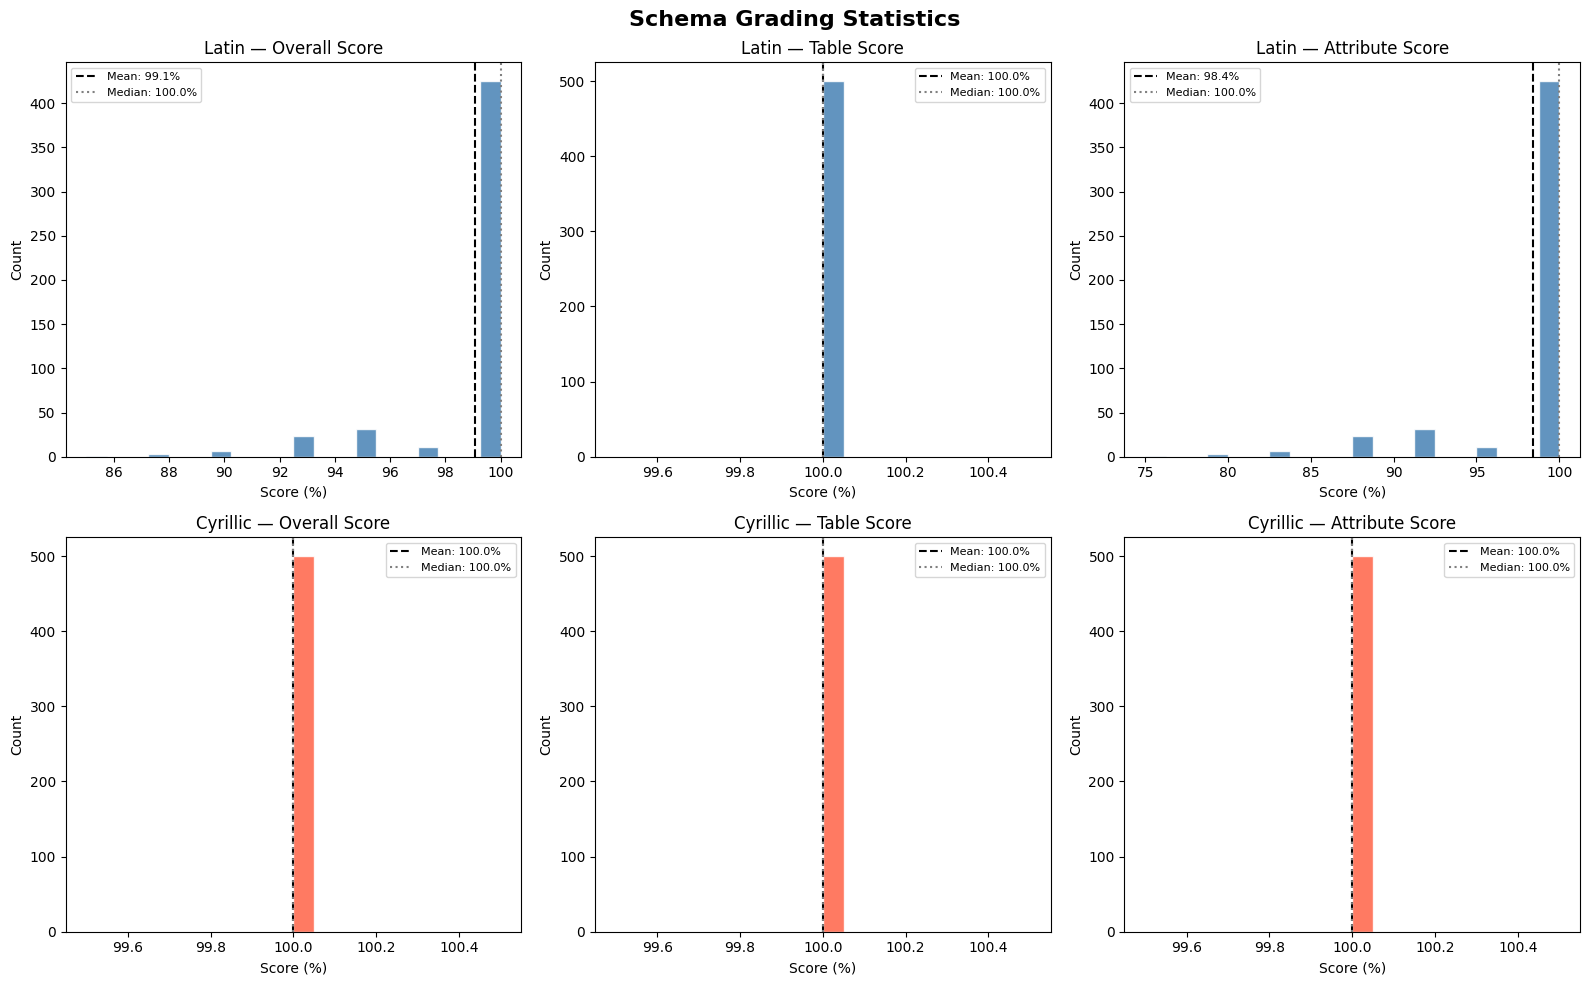

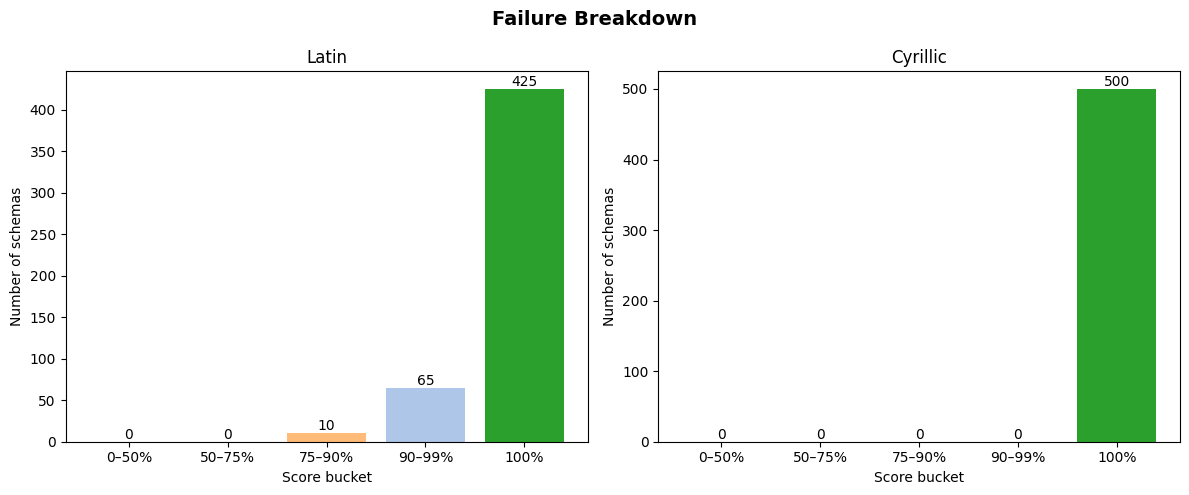


  COMBINED  (n=1000)
  Perfect scores (100%):     925 / 1000  (92.5%)
  Overall score  mean:       99.53%
  Overall score  std:        1.79%
  Overall score  min:        85.00%
  Overall score  median:     100.00%
  Table score    mean:       100.00%
  Attr score     mean:       99.22%
  Avg type mismatches:       0.21
  Schemas w/ type mismatch:  100


In [43]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_results(filepath):
    with open(filepath, 'r', encoding='utf-8') as f:
        return json.load(f)

def parse_score(score_str):
    """Convert '95.0%' -> 95.0"""
    return float(score_str.strip('%'))

def extract_stats(results):
    rows = []
    for r in results:
        scores = r['scores']
        rows.append({
            'schema_id':        r['schema_id'],
            'overall_score':    parse_score(scores['Overall score']),
            'table_score':      parse_score(scores['Table score']),
            'attr_score':       parse_score(scores['Attribute score']),
            'tables_matched':   scores['Tables matched'],
            'attrs_matched':    scores['Attrs matched'],
            'type_mismatches':  int(scores['Type mismatches']),
            'perfect':          parse_score(scores['Overall score']) == 100.0,
        })
    return pd.DataFrame(rows)


def print_summary_stats(df, label):
    print(f"\n{'='*50}")
    print(f"  {label}  (n={len(df)})")
    print(f"{'='*50}")
    print(f"  Perfect scores (100%):     {df['perfect'].sum()} / {len(df)}  ({df['perfect'].mean()*100:.1f}%)")
    print(f"  Overall score  mean:       {df['overall_score'].mean():.2f}%")
    print(f"  Overall score  std:        {df['overall_score'].std():.2f}%")
    print(f"  Overall score  min:        {df['overall_score'].min():.2f}%")
    print(f"  Overall score  median:     {df['overall_score'].median():.2f}%")
    print(f"  Table score    mean:       {df['table_score'].mean():.2f}%")
    print(f"  Attr score     mean:       {df['attr_score'].mean():.2f}%")
    print(f"  Avg type mismatches:       {df['type_mismatches'].mean():.2f}")
    print(f"  Schemas w/ type mismatch:  {(df['type_mismatches'] > 0).sum()}")


def plot_score_distributions(df_lat, df_cyr):
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Schema Grading Statistics', fontsize=16, fontweight='bold')

    metrics = [
        ('overall_score', 'Overall Score'),
        ('table_score',   'Table Score'),
        ('attr_score',    'Attribute Score'),
    ]

    for col, (metric, title) in enumerate(metrics):
        for row, (df, label, color) in enumerate([
            (df_lat, 'Latin',    'steelblue'),
            (df_cyr, 'Cyrillic', 'tomato'),
        ]):
            ax = axes[row][col]
            ax.hist(df[metric], bins=20, color=color, edgecolor='white', alpha=0.85)
            ax.axvline(df[metric].mean(),   color='black', linestyle='--', linewidth=1.5, label=f'Mean: {df[metric].mean():.1f}%')
            ax.axvline(df[metric].median(), color='gray',  linestyle=':',  linewidth=1.5, label=f'Median: {df[metric].median():.1f}%')
            ax.set_title(f'{label} — {title}')
            ax.set_xlabel('Score (%)')
            ax.set_ylabel('Count')
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig('score_distributions.png', dpi=150)
    plt.show()


def plot_failure_breakdown(df_lat, df_cyr):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle('Failure Breakdown', fontsize=14, fontweight='bold')

    for ax, (df, label) in zip(axes, [(df_lat, 'Latin'), (df_cyr, 'Cyrillic')]):
        buckets = pd.cut(df['overall_score'],
                         bins=[0, 50, 75, 90, 99.9, 100],
                         labels=['0–50%', '50–75%', '75–90%', '90–99%', '100%'],
                         include_lowest=True)
        counts = buckets.value_counts().sort_index()
        bars = ax.bar(counts.index, counts.values, color=['#d62728','#ff7f0e','#ffbb78','#aec7e8','#2ca02c'])
        ax.bar_label(bars)
        ax.set_title(label)
        ax.set_xlabel('Score bucket')
        ax.set_ylabel('Number of schemas')

    plt.tight_layout()
    plt.savefig('failure_breakdown.png', dpi=150)
    plt.show()


# ── Run ────────────────────────────────────────────────────────────────────────

latin_results    = load_results('../latin_results_1_500.json')
cyrillic_results = load_results('../cyrillic_results_1_500.json')

df_lat = extract_stats(latin_results)
df_cyr = extract_stats(cyrillic_results)

print_summary_stats(df_lat, "LATIN")
print_summary_stats(df_cyr, "CYRILLIC")

plot_score_distributions(df_lat, df_cyr)
plot_failure_breakdown(df_lat, df_cyr)

# Combined
df_all = pd.concat([df_lat, df_cyr], ignore_index=True)
print_summary_stats(df_all, "COMBINED")